 ---
 ### below FD's and h_bone_max is chosen - and thoughts on it are written in places
 ---
 ### Also 3Dmesh postprocessing edge case is fixedish
 ---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyvista as pv
from pathlib import Path

## Load data

In [2]:
out_dir = Path('outputs/study1')

df_param = pd.read_csv(out_dir / 'params.csv')
df_runtime = pd.read_csv(out_dir / 'runtimes.csv')
print('Max runtime:', f'{df_runtime['runtime'].max():.2f} s')

Max runtime: 26.98 s


#### Combine study Metrics

In [3]:
prefix = ['study1a', 'study1b', 'study1c']
df_bone, df_cart, df_qual = [], [], []
for p in prefix:
    df_bone.append(pd.read_csv(out_dir / f'{p}-boneMetrics.csv'))
    df_cart.append(pd.read_csv(out_dir / f'{p}-cartMetrics.csv'))
    df_qual.append(pd.read_csv(out_dir / f'{p}-qualMetrics.csv'))
df_bone = pd.concat(df_bone).copy()
df_cart = pd.concat(df_cart).copy()
df_qual = pd.concat(df_qual).copy()
df_qual['total_tets'] = df_qual['bone_n_cells'] + df_qual['cart_n_cells']

In [4]:
df_param

,sub,bone,run_id,h_bone_max,d0,fd_cart_near,fd_cart_far,fd_bone,facet_angle,cell_radius_edge_ratio
0,14548R,tpm,0a,0.5,2,0.02,0.01,0.2,7.5,3
1,14548R,tpm,1a,0.5,2,0.02,0.01,0.2,7.5,6
2,14548R,tpm,2a,0.5,2,0.02,0.01,0.2,7.5,12
3,14548R,tpm,3a,0.5,2,0.02,0.01,0.2,15.0,3
4,14548R,tpm,4a,0.5,2,0.02,0.01,0.2,15.0,6
...,...,...,...,...,...,...,...,...,...,...
2182,14548R,tpm,724c,2.0,8,0.08,0.04,0.8,15.0,6
2183,14548R,tpm,725c,2.0,8,0.08,0.04,0.8,15.0,12
2184,14548R,tpm,726c,2.0,8,0.08,0.04,0.8,30.0,3
2185,14548R,tpm,727c,2.0,8,0.08,0.04,0.8,30.0,6


## Select metrics

In [5]:
d_metric = 'max'
iteration_cart = 'remesh2d'
iteration_bone = 'orig'
loc = 'o'

metrics = [

    # fidelity (keep high)
    f'bone_{iteration_bone}_rmsd{loc}',
    f'bone_{iteration_bone}_d{loc}_{d_metric}',
    f'cart_{iteration_cart}_rmsd{loc}',
    f'cart_{iteration_cart}_d{loc}_{d_metric}',

    # quality (keep high)
    'cart_inner_min_angle_worst',
    'cart_inner_scaled_jacobian_worst',

    # cell count (keep low)
    'total_tets'

]


bone = df_bone[
    ['sub', 'bone', 'run_id', f'{iteration_bone}_rmsd{loc}', f'{iteration_bone}_d{loc}_{d_metric}']
].rename(columns={
    f'{iteration_bone}_rmsd{loc}': f'bone_{iteration_bone}_rmsd{loc}',
    f'{iteration_bone}_d{loc}_{d_metric}': f'bone_{iteration_bone}_d{loc}_{d_metric}'
})

cart = df_cart[
    ['sub', 'bone', 'run_id', f'{iteration_cart}_rmsd{loc}', f'{iteration_cart}_d{loc}_{d_metric}']
].rename(columns={
    f'{iteration_cart}_rmsd{loc}': f'cart_{iteration_cart}_rmsd{loc}',
    f'{iteration_cart}_d{loc}_{d_metric}': f'cart_{iteration_cart}_d{loc}_{d_metric}'
})

qual = df_qual[
    [
        'sub', 'bone', 'run_id',
        'cart_inner_min_angle_worst',
        'cart_inner_scaled_jacobian_worst',
        'total_tets'
    ]
]

df = (
    bone
    .merge(cart, on=['sub', 'bone', 'run_id'], how='inner')
    .merge(qual, on=['sub', 'bone', 'run_id'], how='inner')
)

#### Check distributions

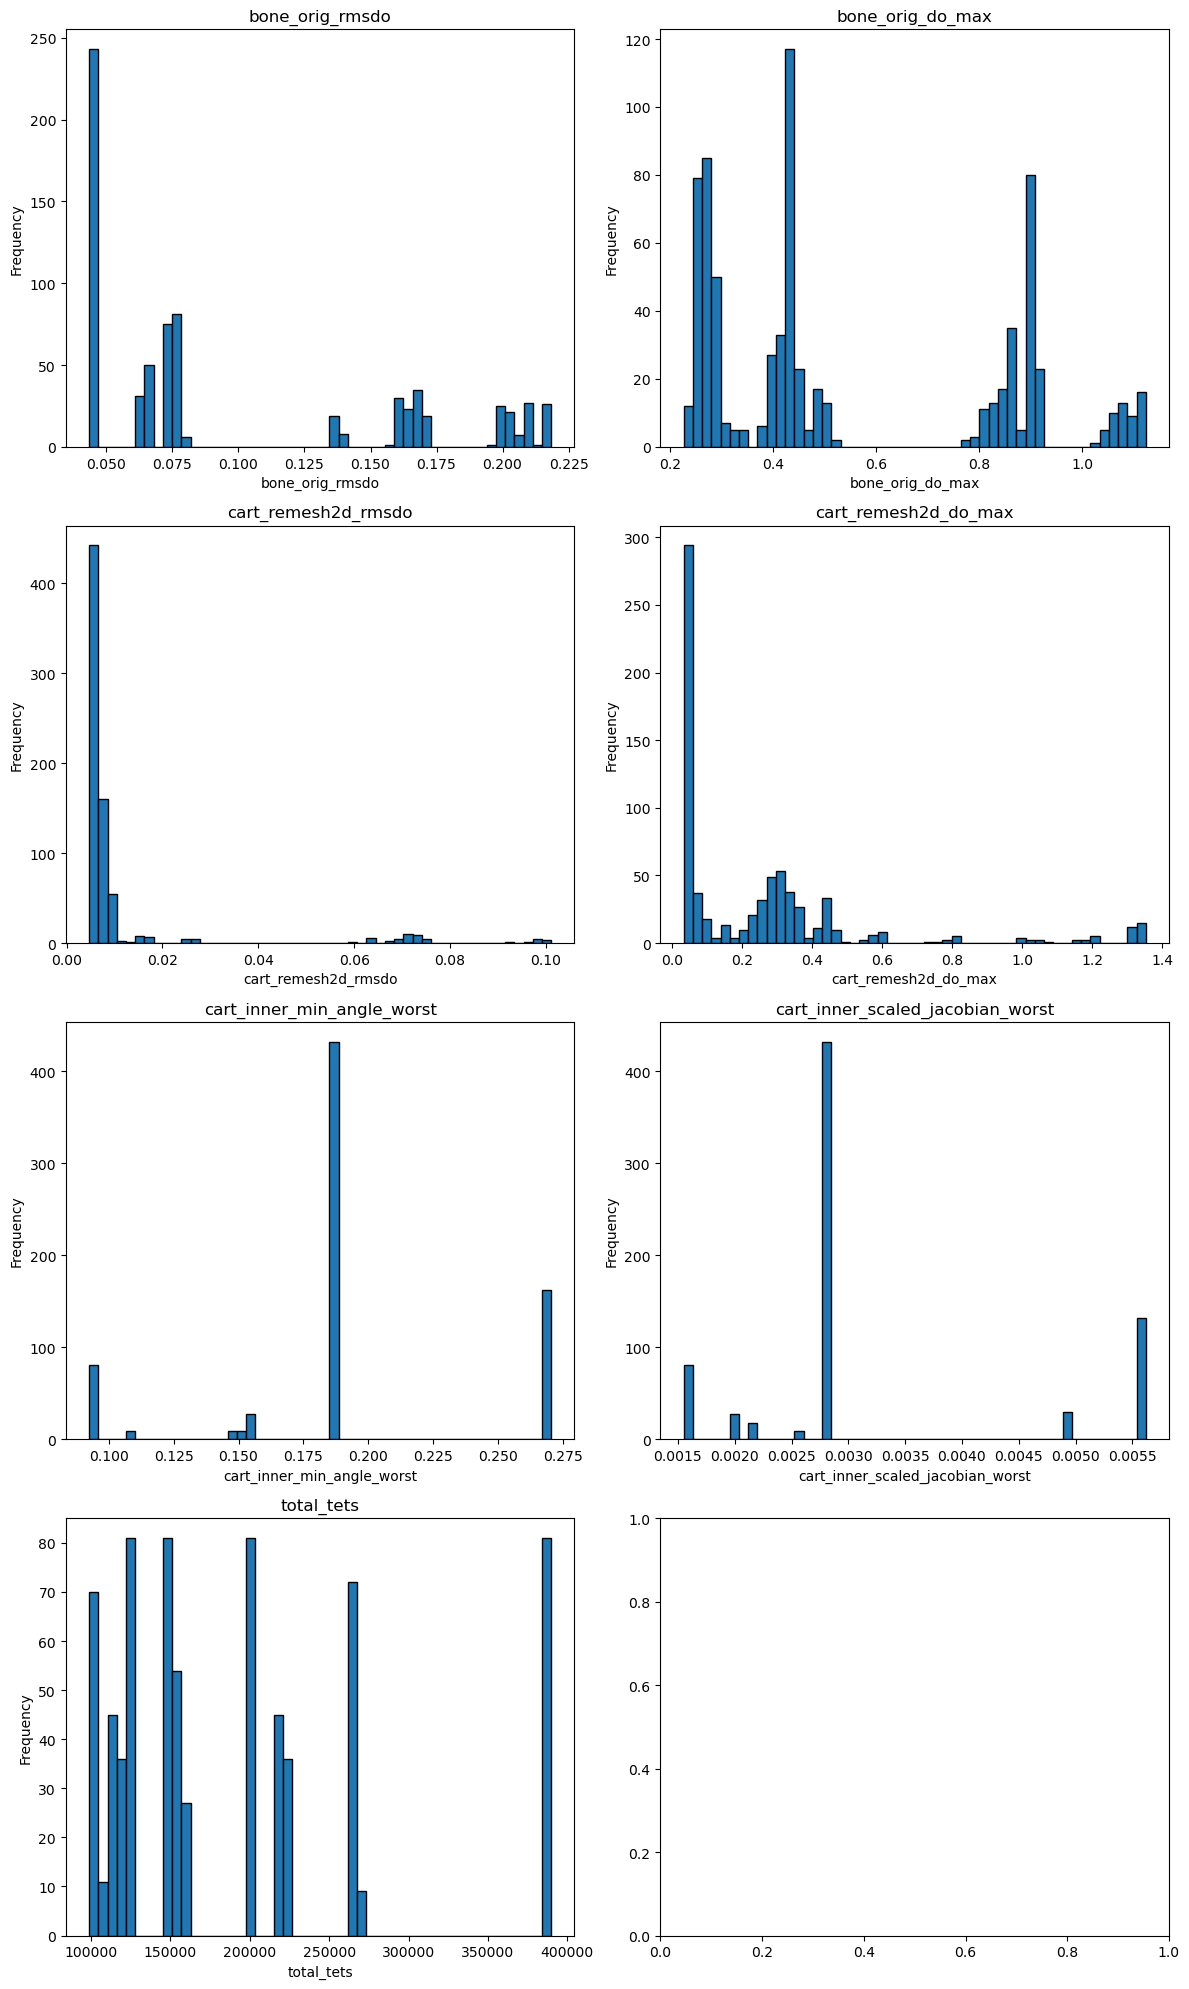

In [6]:
fig, ax = plt.subplots(4, 2, figsize=(12, 20))
ax = ax.flatten()

for i, metric in enumerate(metrics):
    values = df[metric][df_param['fd_bone']==0.8]
    # Histogram
    ax[i].hist(values, bins=50, edgecolor='black')
    ax[i].set_title(metric)
    ax[i].set_xlabel(metric)
    ax[i].set_ylabel('Frequency')


plt.tight_layout()
plt.show()

# How can cart_do_max be so large?

In [ ]:
df_param[df['cart_remesh2d_do_max']>0.6]

,sub,bone,run_id,h_bone_max,d0,fd_cart_near,fd_cart_far,fd_bone,facet_angle,cell_radius_edge_ratio
1458,14548R,tpm,0c,2.0,2,0.02,0.01,0.2,7.5,3
1459,14548R,tpm,1c,2.0,2,0.02,0.01,0.2,7.5,6
1460,14548R,tpm,2c,2.0,2,0.02,0.01,0.2,7.5,12
1461,14548R,tpm,3c,2.0,2,0.02,0.01,0.2,15.0,3
1462,14548R,tpm,4c,2.0,2,0.02,0.01,0.2,15.0,6
...,...,...,...,...,...,...,...,...,...,...
1693,14548R,tpm,235c,2.0,2,0.08,0.04,0.8,7.5,6
1694,14548R,tpm,236c,2.0,2,0.08,0.04,0.8,7.5,12
1695,14548R,tpm,237c,2.0,2,0.08,0.04,0.8,15.0,3
1696,14548R,tpm,238c,2.0,2,0.08,0.04,0.8,15.0,6


#### mystery solved...

In [2]:
mesh = pv.read('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/outputs/ParamOptimisation/criteria3D/study1c/meshes/14548R/tpm-mc1/3Dmesh/mesh-0-0-0.vtu')
mesh_cart_vol = mesh.extract_cells(mesh['region_id']==2)

In [3]:
pl = pv.Plotter()
pl.add_mesh(mesh_cart_vol)
pl.show()


Widget(value='<iframe src="http://localhost:50169/index.html?ui=P_0x109cd0bc0_0&reconnect=auto" class="pyvista…

## Plan
 - Find non-manifold and boudnary edges on cart surf - recursively find any tri with 3 vertices on the combined non-manifold and boundary edge - find the tets that the triangles belong to - assign them to bone
 - This works as long as there is not a chain of tets more than one layer deep that have centres outside of input bone volume and that have a manifold connection between the layers - I think
     - assuming the first layer is always a non-manifold connection to the cartilage... Which I think is always true... but almost definitely not
- check for islands after this step - although this might make checking for islands redundant?

In [ ]:
import numpy as np
import pyvista as pv

def get_bad_face_cell_ids(mesh):
    """takes in mesh after full postprocessing and gets cell ids of any tet faces attached to cartilage that should be part of bone"""

    mesh['mesh_point_id'] = np.arange(mesh.n_points)
    mesh['mesh_cell_id'] = np.arange(mesh.n_cells)
    mesh_shell = mesh.extract_cells_by_type(5)
    mesh_shell['shell_cell_id'] = np.arange(mesh_shell.n_cells)

    bad_ids = []
    while True:
        mesh_cart_shell = mesh_shell.extract_cells(mesh_shell['region_id']==-1, invert=True)
        mesh_cart_surf = mesh_shell.extract_cells(mesh_shell['region_id']==-2).extract_surface(algorithm=None)
        # this gets edges between cart and bad cells if they connect by > 1 point (doesn't get 1 pointers)
        edges_nm = mesh_cart_shell.extract_feature_edges(non_manifold_edges=True, boundary_edges=True, feature_edges=False, manifold_edges=False)
        edges_surf = mesh_cart_surf.extract_feature_edges(non_manifold_edges=False, boundary_edges=True, feature_edges=False, manifold_edges=False)
        edges = edges_nm + edges_surf

        boundary_ids = edges['mesh_point_id'][edges.lines.reshape(-1, 3)[:, 1:]] # on surf
        bad_mask = np.isin(mesh_cart_surf['mesh_point_id'][mesh_cart_surf.regular_faces], boundary_ids).sum(axis=1) >= 3 # on surf

        if bad_mask.any():
            bad = np.where(bad_mask)[0]
            #print(len(bad))
            bad_ids.extend(mesh_cart_surf['mesh_cell_id'][bad])
            mesh_shell = mesh_shell.extract_cells(~np.isin(mesh_shell['shell_cell_id'], mesh_cart_surf['shell_cell_id'][bad]))
        else:
            break

    return bad_ids

def get_bad_tet_cell_mask(mesh, bad_face_cell_ids):
    """takes in mesh after full postprocessing and gets cell mask of any tets attached to cartilage that should be part of bone"""

    mask = np.zeros(mesh.n_cells, dtype=bool)
    #if len(bad_face_cell_ids) == 0:
    #    return mask

    bad_tris = np.array([mesh.get_cell(cid).point_ids for cid in bad_face_cell_ids]) # on mesh

    bad_tris_sorted = np.sort(bad_tris, axis=1)
    bad_tri_set = {tuple(row) for row in bad_tris_sorted}

    tet_cell_ids = np.where(mesh.celltypes == pv.CellType.TETRA)[0]
    tets = mesh.cells_dict[pv.CellType.TETRA]   # shape (n_tets, 4)

    tet_faces = np.vstack([
        tets[:, [0, 1, 2]],
        tets[:, [0, 1, 3]],
        tets[:, [0, 2, 3]],
        tets[:, [1, 2, 3]],
    ])
    tet_faces = np.sort(tet_faces, axis=1)

    face_matches = np.array([tuple(face) in bad_tri_set for face in tet_faces])
    tet_mask = face_matches.reshape(4, -1).any(axis=0)

    mask[tet_cell_ids] = tet_mask

    return mask

from phd_helpers.paths import find_shared_cells, identical_points_count

def rebuild_combined_mesh(mesh):
    """takes in mesh with reassigned edge case cells and outputs the final combined mesh"""

    tet = mesh.extract_cells_by_type(10)
    cartilage_tet = tet.extract_cells(tet['region_id']==2)
    bone_tet = tet.extract_cells(tet['region_id']==1)


    # extract volume shells for surface meshes
    cartilage_shell = cartilage_tet.extract_surface(algorithm=None) # cartilage shell
    bone_shell = bone_tet.extract_surface(algorithm=None) # bone shell
    #tet_shell = tet.extract_surface(algorithm=None) # tet shell

    # find interface surfaces on cartilage and bone
    interface_mask_bone = find_shared_cells(bone_shell, cartilage_shell)
    interface_mask_cartilage = find_shared_cells(cartilage_shell, bone_shell)
    interface_bone = bone_shell.extract_cells(interface_mask_bone)
    interface_cartilage = cartilage_shell.extract_cells(interface_mask_cartilage)
    # check they are identical
    n_shared = identical_points_count(interface_cartilage.points, interface_bone.points)
    if n_shared != interface_bone.n_points and n_shared == interface_cartilage.n_points:
        raise AssertionError('Interfaces are not identical')
    # assign bone interface to interface surf for consistency (normals point outwards relative to bone)
    interface_surf = interface_bone
    interface_surf['region_id'] = np.full(interface_surf.n_cells, -3)

    # extract bone and cartilage surfs
    bone_surf = bone_shell.extract_cells(~interface_mask_bone)
    bone_surf['region_id'] = np.full(bone_surf.n_cells, -1)
    cartilage_surf = cartilage_shell.extract_cells(~interface_mask_cartilage)
    cartilage_surf['region_id'] = np.full(cartilage_surf.n_cells, -2)

    # combined mesh of tets and tris with region ids - ••• Needs to be tets then tris for abaqus input script to work •••
    combined = tet + interface_surf + bone_surf + cartilage_surf
    return combined

def ad_hoc_mesh_fix(mesh):
    """takes in final postprocessed mesh and postprocesses again..."""
    # assign tets that were outside of input bone volume and attached to cartilage to bone (defo some edge cases that it still won't work for...)
    bad_ids = get_bad_face_cell_ids(mesh)
    if len(bad_ids) == 0:
        return mesh
    tet_mask = get_bad_tet_cell_mask(mesh, bad_ids)
    mesh['region_id'][(mesh['region_id']==2) & tet_mask] = 1
    return rebuild_combined_mesh(mesh)
    

In [6]:
mesh1 = ad_hoc_mesh_fix(mesh)

In [9]:
mesh1.extract_cells_by_type(5).plot(scalars='region_id')

Widget(value='<iframe src="http://localhost:50169/index.html?ui=P_0x329d11f40_3&reconnect=auto" class="pyvista…

### Check implementation in mesh3D
 - ran for two different params that had bad cells before and worked for both

In [14]:
import subprocess
path_MeshPipeline_main = '../../../../MeshPipeline/main.py'
subprocess.run(["python", path_MeshPipeline_main])


Updating parameters.json
	Wrote /Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/set_parameters/parameters.json


Full parameter file saved to outputs/3Dmesh_postprocess_test/params/full_params-2.json

SUBJECT: 14548R
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 2.678s - ok
		STEP: cartilage
			RUN ID: -0-0
			Runtime: 2.642s - ok
		STEP: 3Dmesh
			RUN ID: -0-0-0
			Runtime: 12.704s - ok


CompletedProcess(args=['python', '../../../../MeshPipeline/main.py'], returncode=0)

In [15]:
mesh = pv.read('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/notebooks/MeshPipeline/ParamOptimisation/criteria3D/outputs/3Dmesh_postprocess_test/meshes/14548R/tpm-mc1/3Dmesh/mesh-0-0-0.vtu')



In [18]:
mesh.plot(scalars='region_id')

Widget(value='<iframe src="http://localhost:50169/index.html?ui=P_0x334244a40_7&reconnect=auto" class="pyvista…

# Determine facet distances
 - fd_bone = 1 
    - cos of stuff in last section of this notebook
 ---
 - fd_cart_near = 0.10
   - 0.10 seems like it would be reasonable - considering the height here is only an approximation and the average midpoint dist was 0.5 at edge of inner so allows around 20% deviation either side
 ---
 - fd_cart_far = 0.05
    - for values up to 0.04, max deviation for inner cart from smooth/remesh is < 0.01 and from orig is < 0.04, which is obv same deviation as remesh from orig.
    - so probably just say max allowed deviation from orig is 0.05 (< 10% of average cartilage height) and set fd to that?

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


out_dir = Path('outputs/study1-meshFix')

df_param = pd.read_csv(out_dir / 'params.csv')
df_runtime = pd.read_csv(out_dir / 'runtimes.csv')
print('Max runtime:', f'{df_runtime['runtime'].max():.2f} s')

prefix = ['study1a', 'study1b', 'study1c']
df_bone, df_cart, df_qual = [], [], []
for p in prefix:
    df_bone.append(pd.read_csv(out_dir / f'{p}-boneMetrics.csv'))
    df_cart.append(pd.read_csv(out_dir / f'{p}-cartMetrics.csv'))
    df_qual.append(pd.read_csv(out_dir / f'{p}-qualMetrics.csv'))
df_bone = pd.concat(df_bone).copy()
df_cart = pd.concat(df_cart).copy()
df_qual = pd.concat(df_qual).copy()
df_qual['total_tets'] = df_qual['bone_n_cells'] + df_qual['cart_n_cells']

df_param

Max runtime: 26.98 s


,sub,bone,run_id,h_bone_max,d0,fd_cart_near,fd_cart_far,fd_bone,facet_angle,cell_radius_edge_ratio
0,14548R,tpm,0a,0.5,2,0.02,0.01,0.2,7.5,3
1,14548R,tpm,1a,0.5,2,0.02,0.01,0.2,7.5,6
2,14548R,tpm,2a,0.5,2,0.02,0.01,0.2,7.5,12
3,14548R,tpm,3a,0.5,2,0.02,0.01,0.2,15.0,3
4,14548R,tpm,4a,0.5,2,0.02,0.01,0.2,15.0,6
...,...,...,...,...,...,...,...,...,...,...
2182,14548R,tpm,724c,2.0,8,0.08,0.04,0.8,15.0,6
2183,14548R,tpm,725c,2.0,8,0.08,0.04,0.8,15.0,12
2184,14548R,tpm,726c,2.0,8,0.08,0.04,0.8,30.0,3
2185,14548R,tpm,727c,2.0,8,0.08,0.04,0.8,30.0,6


In [ ]:
d_metric = 'max'
iteration_cart = 'remesh2d'
iteration_bone = 'remesh2d'
loc = 'i'

qual_metric = '99%'

metrics = [

    # fidelity (keep high)
    f'bone_{iteration_bone}_rmsd{loc}',
    f'bone_{iteration_bone}_d{loc}_{d_metric}',
    f'cart_{iteration_cart}_rmsd{loc}',
    f'cart_{iteration_cart}_d{loc}_{d_metric}',

    # quality (keep high)
    f'cart_inner_min_angle_{qual_metric}',
    f'cart_inner_scaled_jacobian_{qual_metric}',

    # cell count (keep low)
    'total_tets'

]


bone = df_bone[
    ['sub', 'bone', 'run_id', f'{iteration_bone}_rmsd{loc}', f'{iteration_bone}_d{loc}_{d_metric}']
].rename(columns={
    f'{iteration_bone}_rmsd{loc}': f'bone_{iteration_bone}_rmsd{loc}',
    f'{iteration_bone}_d{loc}_{d_metric}': f'bone_{iteration_bone}_d{loc}_{d_metric}'
})

cart = df_cart[
    ['sub', 'bone', 'run_id', f'{iteration_cart}_rmsd{loc}', f'{iteration_cart}_d{loc}_{d_metric}']
].rename(columns={
    f'{iteration_cart}_rmsd{loc}': f'cart_{iteration_cart}_rmsd{loc}',
    f'{iteration_cart}_d{loc}_{d_metric}': f'cart_{iteration_cart}_d{loc}_{d_metric}'
})

qual = df_qual[
    [
        'sub', 'bone', 'run_id',
        f'cart_inner_min_angle_{qual_metric}',
        f'cart_inner_scaled_jacobian_{qual_metric}',
        'total_tets'
    ]
]

df = (
    bone
    .merge(cart, on=['sub', 'bone', 'run_id'], how='inner')
    .merge(qual, on=['sub', 'bone', 'run_id'], how='inner')
)

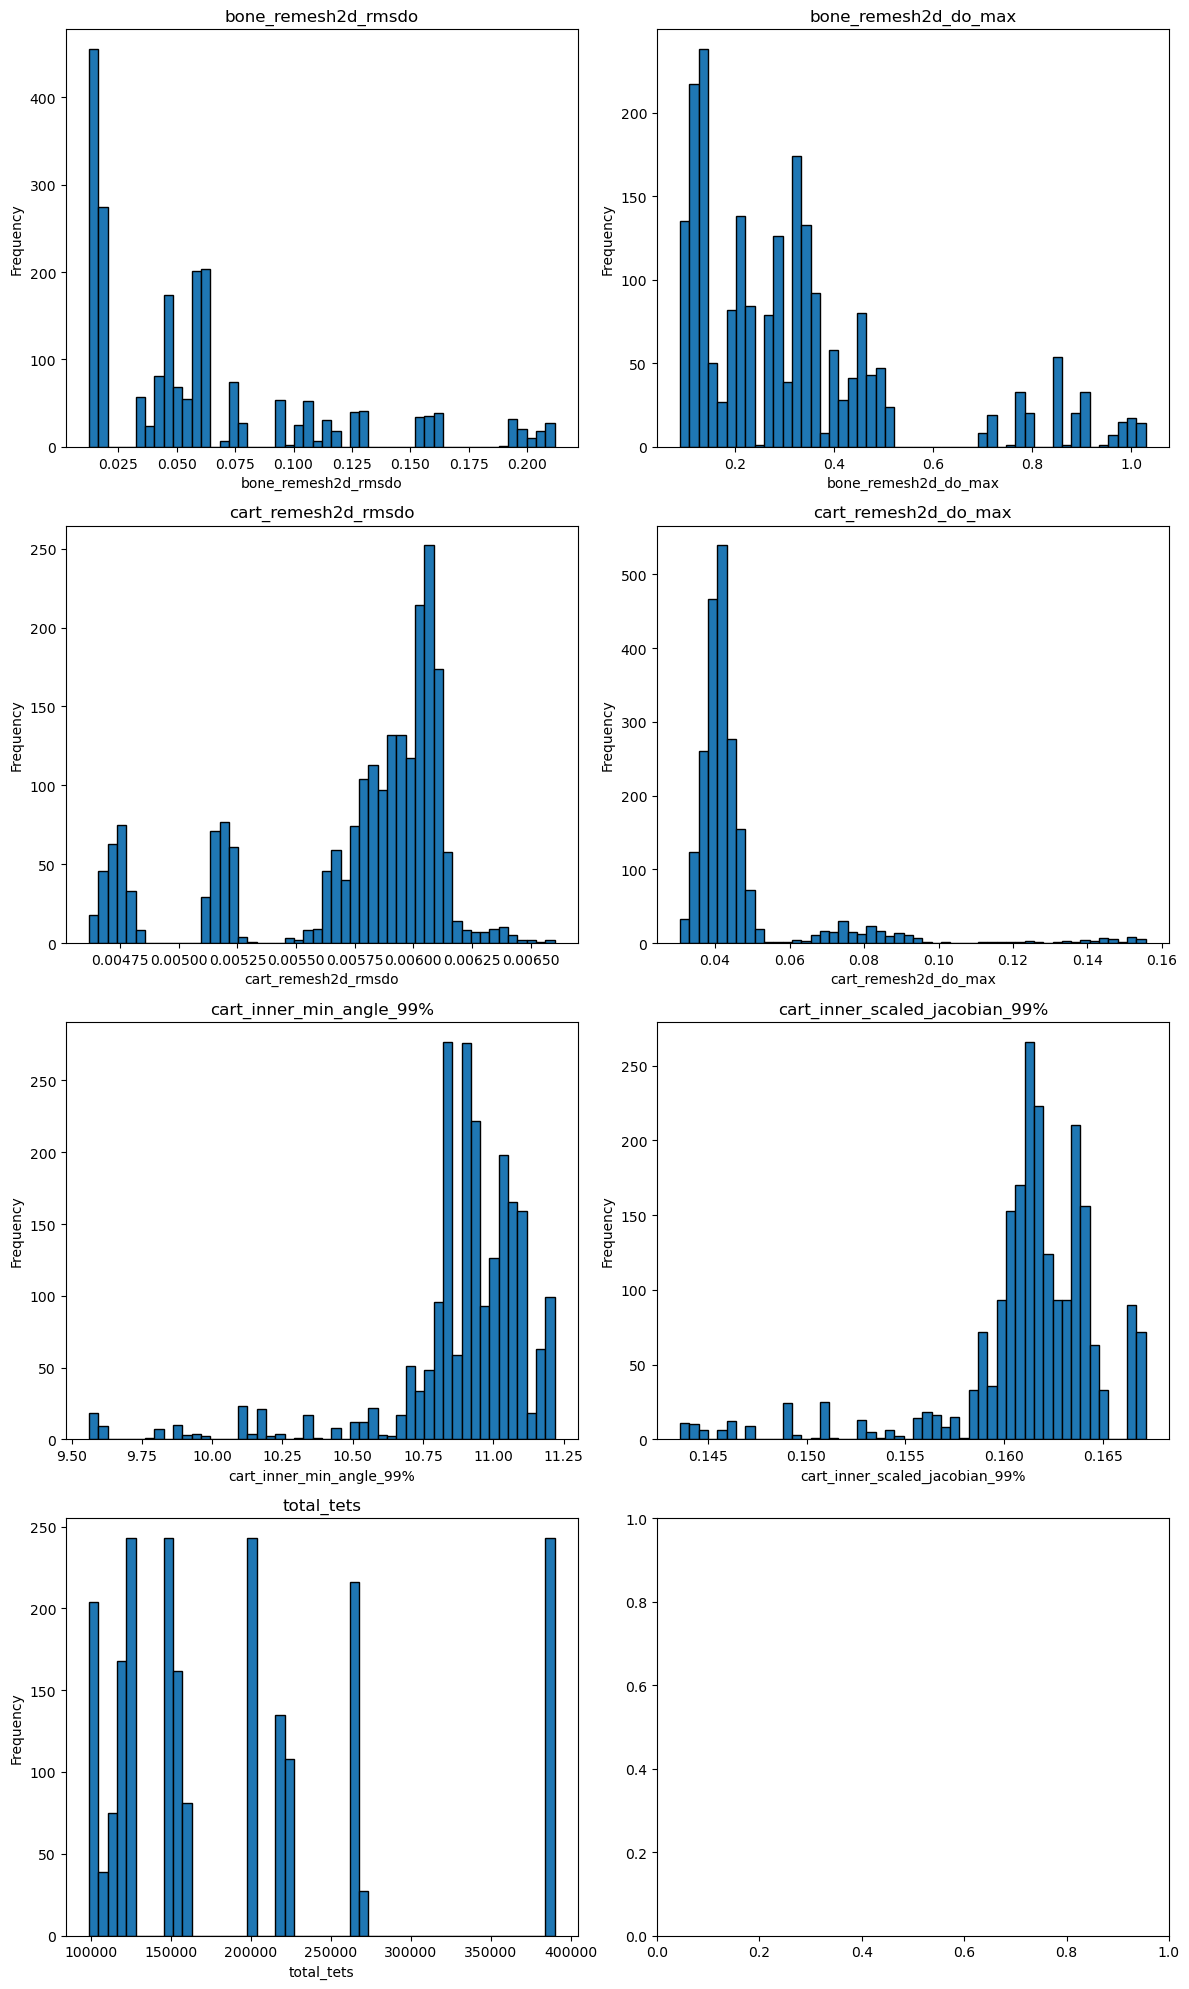

In [24]:
fig, ax = plt.subplots(4, 2, figsize=(12, 20))
ax = ax.flatten()

for i, metric in enumerate(metrics):
    values = df[metric]#[df_param['fd_bone']==0.8]
    # Histogram
    ax[i].hist(values, bins=50, edgecolor='black')
    ax[i].set_title(metric)
    ax[i].set_xlabel(metric)
    ax[i].set_ylabel('Frequency')


plt.tight_layout()
plt.show()

In [29]:
df_param[df['cart_inner_scaled_jacobian_99%']>0.166]

,sub,bone,run_id,h_bone_max,d0,fd_cart_near,fd_cart_far,fd_bone,facet_angle,cell_radius_edge_ratio
6,14548R,tpm,6a,0.5,2,0.02,0.01,0.2,30.0,3
7,14548R,tpm,7a,0.5,2,0.02,0.01,0.2,30.0,6
8,14548R,tpm,8a,0.5,2,0.02,0.01,0.2,30.0,12
15,14548R,tpm,15a,0.5,2,0.02,0.01,0.4,30.0,3
16,14548R,tpm,16a,0.5,2,0.02,0.01,0.4,30.0,6
...,...,...,...,...,...,...,...,...,...,...
475,14548R,tpm,475a,0.5,4,0.08,0.04,0.4,30.0,6
476,14548R,tpm,476a,0.5,4,0.08,0.04,0.4,30.0,12
483,14548R,tpm,483a,0.5,4,0.08,0.04,0.8,30.0,3
484,14548R,tpm,484a,0.5,4,0.08,0.04,0.8,30.0,6


# Determine resonable d0 - bone growth region width
 - above shows that the little influence this step has on mesh quality, is largely driven by the sharpness of the transition from cartilage to bone
 - need to figure out what reasonable set of values for d0 to investigate are
    - reasonable based on not too many cells
 - keep in mind, decided below that h_bone_max = 1.0
 - Not looking good - cell counts look like they will be high
     - will just have to look at [2, 4, 8]

In [ ]:
# every run with h_bone_max = 0.5 and d0

df_param[df['total_tets'] > 300000]

,sub,bone,run_id,h_bone_max,d0,fd_cart_near,fd_cart_far,fd_bone,facet_angle,cell_radius_edge_ratio
486,14548R,tpm,486a,0.5,8,0.02,0.01,0.2,7.5,3
487,14548R,tpm,487a,0.5,8,0.02,0.01,0.2,7.5,6
488,14548R,tpm,488a,0.5,8,0.02,0.01,0.2,7.5,12
489,14548R,tpm,489a,0.5,8,0.02,0.01,0.2,15.0,3
490,14548R,tpm,490a,0.5,8,0.02,0.01,0.2,15.0,6
...,...,...,...,...,...,...,...,...,...,...
724,14548R,tpm,724a,0.5,8,0.08,0.04,0.8,15.0,6
725,14548R,tpm,725a,0.5,8,0.08,0.04,0.8,15.0,12
726,14548R,tpm,726a,0.5,8,0.08,0.04,0.8,30.0,3
727,14548R,tpm,727a,0.5,8,0.08,0.04,0.8,30.0,6


In [ ]:
# d0 8 would be in this range and 8 covers whole of this tpm bone (small bone)

df_param[(df['total_tets'] > 150000) & (df['total_tets'] < 175000)]

,sub,bone,run_id,h_bone_max,d0,fd_cart_near,fd_cart_far,fd_bone,facet_angle,cell_radius_edge_ratio
972,14548R,tpm,243b,1.0,4,0.02,0.01,0.2,7.5,3
973,14548R,tpm,244b,1.0,4,0.02,0.01,0.2,7.5,6
974,14548R,tpm,245b,1.0,4,0.02,0.01,0.2,7.5,12
975,14548R,tpm,246b,1.0,4,0.02,0.01,0.2,15.0,3
976,14548R,tpm,247b,1.0,4,0.02,0.01,0.2,15.0,6
...,...,...,...,...,...,...,...,...,...,...
1969,14548R,tpm,511c,2.0,8,0.02,0.01,0.8,30.0,6
1970,14548R,tpm,512c,2.0,8,0.02,0.01,0.8,30.0,12
1977,14548R,tpm,519c,2.0,8,0.02,0.02,0.2,30.0,3
1978,14548R,tpm,520c,2.0,8,0.02,0.02,0.2,30.0,6


# Determine max bone cell size
Find a max cell size that doesn't require an unreasonable facet distance


 - measure the gdist of bone points from boudnary, get bone points far enough away that arn't influenced by refined cartilage mesh (also don't care about cells that are certain to be in the final taper region)
     - look at cell sizes in this 
     
 - Both 0.25 and 1.0 have same cell size ranges when max size = 5.0 - ranges are too big to be sure of smooth size transitions between them
 - FD of 0.25 requires too much refinement in certain areas
 - FD of 1.0 results in resonable fidelity everywhere
 - Therefore, set FD to 1.0 and max cell size to 1.0 -> 1.5 ? 
    - This isn't too much larger than the small cell sizes needed for curved region, and prevents extreme cell size jumps between regions.
    - checking how they look below
         - cell count differences for h_bone_max=1.0->1.5 are close to negligable so might aswell user smaller limit for better transitions
        - 1.0 gives: low cell count and round number and no big size jumps from curved to flat
 - Therefore set h_bone_max = 1.0

---
- This also shows that once d0 hits ~8->10 mm that covers the whole distance

### Run with fd_bone: [0.25, 0.50, 1.0] ; "h_bone_max": 5.0

In [69]:
import subprocess
path_MeshPipeline_main = '../../../../MeshPipeline/main.py'
subprocess.run(["python", path_MeshPipeline_main])


Updating parameters.json
	Wrote /Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/set_parameters/parameters.json


Full parameter file saved to outputs/fd_test/test1/params/full_params-3.json

SUBJECT: 14548R
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 1.547s - ok
		STEP: cartilage
			RUN ID: -0-0
			Runtime: 1.507s - ok
		STEP: 3Dmesh
			RUN ID: -0-0-0
			Runtime: 7.295s - ok
			RUN ID: -0-0-1
			Runtime: 7.486s - ok
			RUN ID: -0-0-2
			Runtime: 7.570s - ok


CompletedProcess(args=['python', '../../../../MeshPipeline/main.py'], returncode=0)

In [155]:
root_dir = Path('outputs/fd_test/test1') # path to parent of output_root in set_parameters


sub = '14548R'
bones = 'tpm-mc1'

mesh3d_025 = pv.read(root_dir / f'meshes/{sub}/{bones}/3Dmesh/mesh-0-0-0.vtu').extract_cells_by_type(5)
mesh3d_05 = pv.read(root_dir / f'meshes/{sub}/{bones}/3Dmesh/mesh-0-0-1.vtu').extract_cells_by_type(5)
mesh3d_10 = pv.read(root_dir / f'meshes/{sub}/{bones}/3Dmesh/mesh-0-0-2.vtu').extract_cells_by_type(5)

In [173]:
import gdist
from scipy.spatial.distance import cdist

mesh = mesh3d_10
bone_surf = mesh.extract_cells(mesh['region_id']==-1).extract_surface(algorithm=None)
boundary_ids = np.arange(bone_surf.n_points)[np.where(bone_surf.point_data['medit:ref']==-1)]

geo_dists = gdist.compute_gdist(
    bone_surf.points.astype(np.float64),
    bone_surf.faces.reshape(-1, 4)[:, 1:].astype(np.int32),
    source_indices=boundary_ids.astype(np.int32), 
) 
dists = cdist(bone_surf.points, bone_surf.points[boundary_ids]).min(axis=1)

mask = geo_dists >= 3.5
mask = dists >= 8

base = bone_surf.extract_points(mask, adjacent_cells=False).extract_surface(algorithm=None)
A = base.compute_cell_sizes(length=False, volume=False)["Area"]

# circumradius
R = np.sqrt(4 * A / (3 * np.sqrt(3))) 
print(f'Min size = {R.min():.4f}')
print(f'Max size = {R.max():.4f}')

Min size = 1.4296
Max size = 2.0831


In [174]:
p = np.array([75.5, 67.2, 84.0])

pl = pv.Plotter()
pl.add_mesh(base, show_edges=True, color='green')
pl.add_points(p, point_size=20, render_points_as_spheres=True)
pl.camera_position = pv.CameraPosition(position=(80.04865720184003, 47.95326722496728, 93.54402720387564),
               focal_point=(75.04026004178999, 73.30120446284118, 83.84261594582057),
               viewup=(0.6375877382829819, 0.3820194923524485, 0.668986534583447))
pl.add_axes()
print(R[base.find_closest_cell(p)])
pl.show()

1.5888527199735976


Widget(value='<iframe src="http://localhost:62186/index.html?ui=P_0x3c2619220_78&reconnect=auto" class="pyvist…

### Run again with "h_bone_max": [0.8, 1.0, 1.25, 1.5] ; fd_bone: 1.0

In [150]:
import subprocess
path_MeshPipeline_main = '../../../../MeshPipeline/main.py'
subprocess.run(["python", path_MeshPipeline_main])


Updating parameters.json
	Wrote /Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/set_parameters/parameters.json


Full parameter file saved to outputs/fd_test/test2/params/full_params-2.json

SUBJECT: 14548R
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 1.511s - ok
		STEP: cartilage
			RUN ID: -0-0
			Runtime: 1.645s - ok
		STEP: 3Dmesh
			RUN ID: -0-0-0
			Runtime: 7.845s - ok
			RUN ID: -0-0-1
			Runtime: 7.386s - ok
			RUN ID: -0-0-2
			Runtime: 7.435s - ok
			RUN ID: -0-0-3
			Runtime: 7.353s - ok


CompletedProcess(args=['python', '../../../../MeshPipeline/main.py'], returncode=0)

In [151]:
root_dir = Path('outputs/fd_test/test2') # path to parent of output_root in set_parameters


sub = '14548R'
bones = 'tpm-mc1'

mesh3d_08 = pv.read(root_dir / f'meshes/{sub}/{bones}/3Dmesh/mesh-0-0-0.vtu').extract_cells_by_type(10)
mesh3d_10 = pv.read(root_dir / f'meshes/{sub}/{bones}/3Dmesh/mesh-0-0-1.vtu').extract_cells_by_type(10)
mesh3d_125 = pv.read(root_dir / f'meshes/{sub}/{bones}/3Dmesh/mesh-0-0-2.vtu').extract_cells_by_type(10)
mesh3d_15 = pv.read(root_dir / f'meshes/{sub}/{bones}/3Dmesh/mesh-0-0-3.vtu').extract_cells_by_type(10)

print(mesh3d_08.n_cells)
print(mesh3d_10.n_cells)
print(mesh3d_125.n_cells)
print(mesh3d_15.n_cells)

116743
111385
108982
107832


#### cell count differences are close to negligable so might aswell user smaller limit for better transitions
 - Let's use 1.0
    - low cell count and round number and no big size jumps from curved to flat

In [152]:
p = np.array([75.5, 67.2, 84.0])

pl = pv.Plotter()
pl.add_mesh(mesh3d_08, show_edges=True)
pl.add_points(p, point_size=20, render_points_as_spheres=True)
pl.camera_position = pv.CameraPosition(position=(80.04865720184003, 47.95326722496728, 93.54402720387564),
               focal_point=(75.04026004178999, 73.30120446284118, 83.84261594582057),
               viewup=(0.6375877382829819, 0.3820194923524485, 0.668986534583447))
pl.add_axes()
print(R[base.find_closest_cell(p)])
pl.show()

0.8062851776589043


Widget(value='<iframe src="http://localhost:62186/index.html?ui=P_0x3a1ebca70_68&reconnect=auto" class="pyvist…

In [153]:
p = np.array([75.5, 67.2, 84.0])

pl = pv.Plotter()
pl.add_mesh(mesh3d_10, show_edges=True)
pl.add_points(p, point_size=20, render_points_as_spheres=True)
pl.camera_position = pv.CameraPosition(position=(80.04865720184003, 47.95326722496728, 93.54402720387564),
               focal_point=(75.04026004178999, 73.30120446284118, 83.84261594582057),
               viewup=(0.6375877382829819, 0.3820194923524485, 0.668986534583447))
pl.add_axes()
print(R[base.find_closest_cell(p)])
pl.show()

0.8062851776589043


Widget(value='<iframe src="http://localhost:62186/index.html?ui=P_0x39fca5fa0_69&reconnect=auto" class="pyvist…